In [5]:
# Inštalácia knižnice hmmlearn
!pip install hmmlearn

# Import knižníc
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import importlib.util
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Načítanie FHMM modelu zo súboru fhmm_model.py
spec = importlib.util.spec_from_file_location("fhmm_model", "fhmm_model.py")
fhmm_model = importlib.util.module_from_spec(spec)
spec.loader.exec_module(fhmm_model)

# Načítanie a spojenie tréningových datasetov (0–5)
train_dfs = []
for i in range(6):
    path = f"standardized_house1_{i}.csv"
    df = pd.read_csv(path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    train_dfs.append(df)

train_df_combined = pd.concat(train_dfs, ignore_index=True)

# Zoznam spotrebičov
appliance_list = [col for col in train_df_combined.columns if col not in ['timestamp', 'main', 'Unnamed: 0']]            

# Inicializácia a trénovanie FHMM modelu
model2 = fhmm_model.FHMM(debug=True)
model2.train(train_df_combined, appliance_list)

# Načítanie testovacieho datasetu (dataset 6)
test_df = pd.read_csv("standardized_house1_6.csv")
test_df['timestamp'] = pd.to_datetime(test_df['timestamp'])
test_df['power'] = test_df['main']

# Disaggregácia
predictions = model2.disaggregate(test_df)

# Vyhodnotenie presnosti
sum_disagg = predictions.sum(axis=1)
mae = mean_absolute_error(test_df['main'], sum_disagg)
mse = mean_squared_error(test_df['main'], sum_disagg)
rmse = np.sqrt(mse)


print("\nVýsledky disaggregácie (FHMM model, house1_6):")
print(f"MAE: {mae:.2f} W")
print(f"MSE: {mse:.2f} W²")
print(f"RMSE: {rmse:.2f} W")

[FHMM Initialised]
 [train] Training model for submeter dish washer
 [train] Training model for submeter electric space heater
 [train] Training model for submeter electric stove
 [train] Training model for submeter fridge
 [train] Training model for submeter microwave
 [train] Training model for submeter washer dryer

Výsledky disaggregácie (FHMM model, house1_6):
MAE: 348.63 W
MSE: 1730152.60 W²
RMSE: 1315.35 W


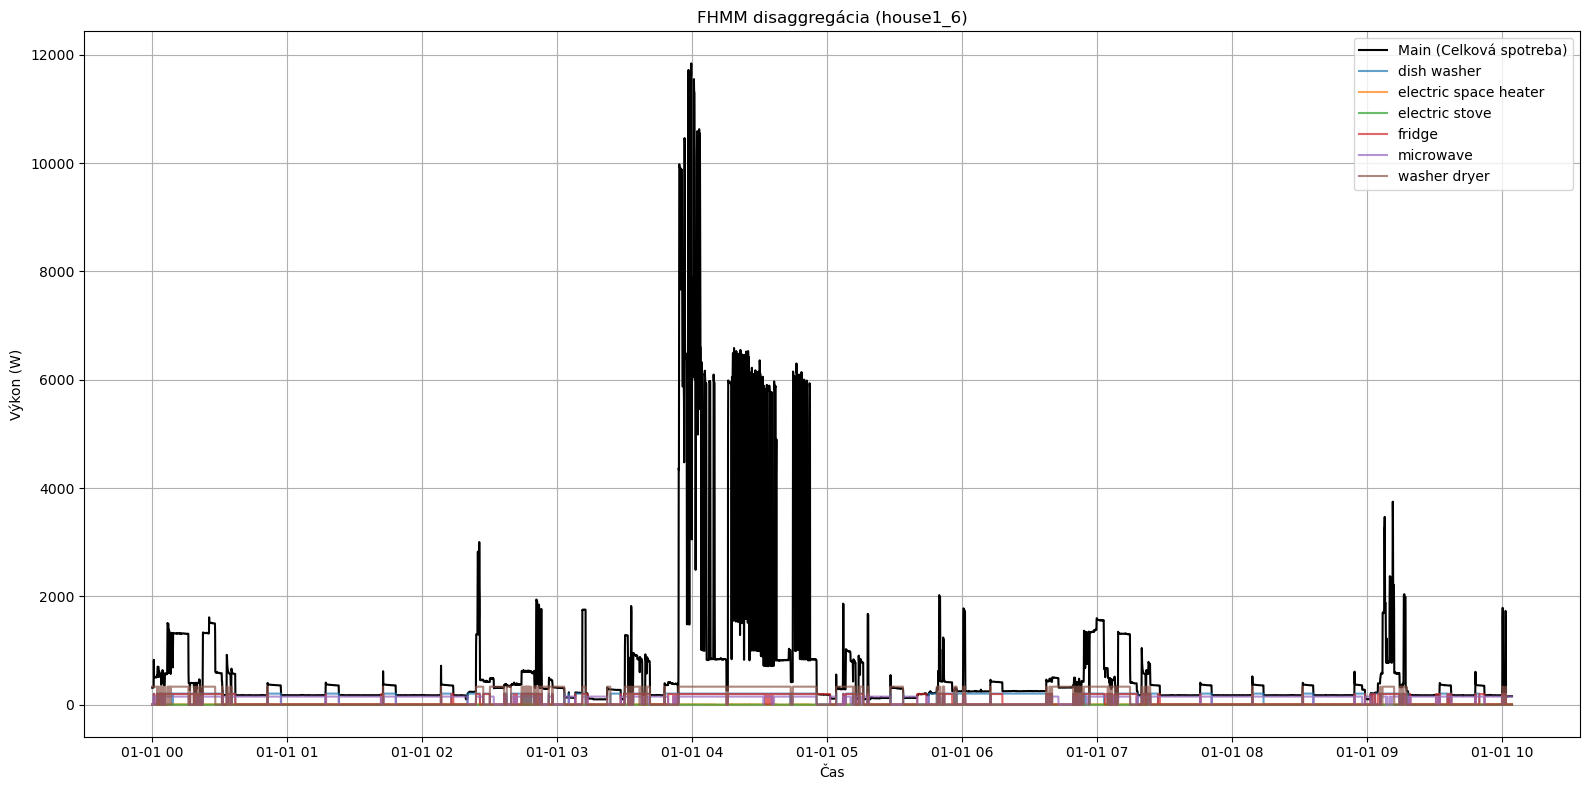

In [9]:

# Vizualizácia disaggregácie
plt.figure(figsize=(16, 8))
plt.plot(test_df['timestamp'], test_df['main'], label='Main (Celková spotreba)', color='black')    
for appliance in appliance_list:
    plt.plot(predictions.index, predictions[appliance], label=appliance, alpha=0.7)
plt.xlabel('Čas')
plt.ylabel('Výkon (W)')
plt.title('FHMM disaggregácia (house1_6)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


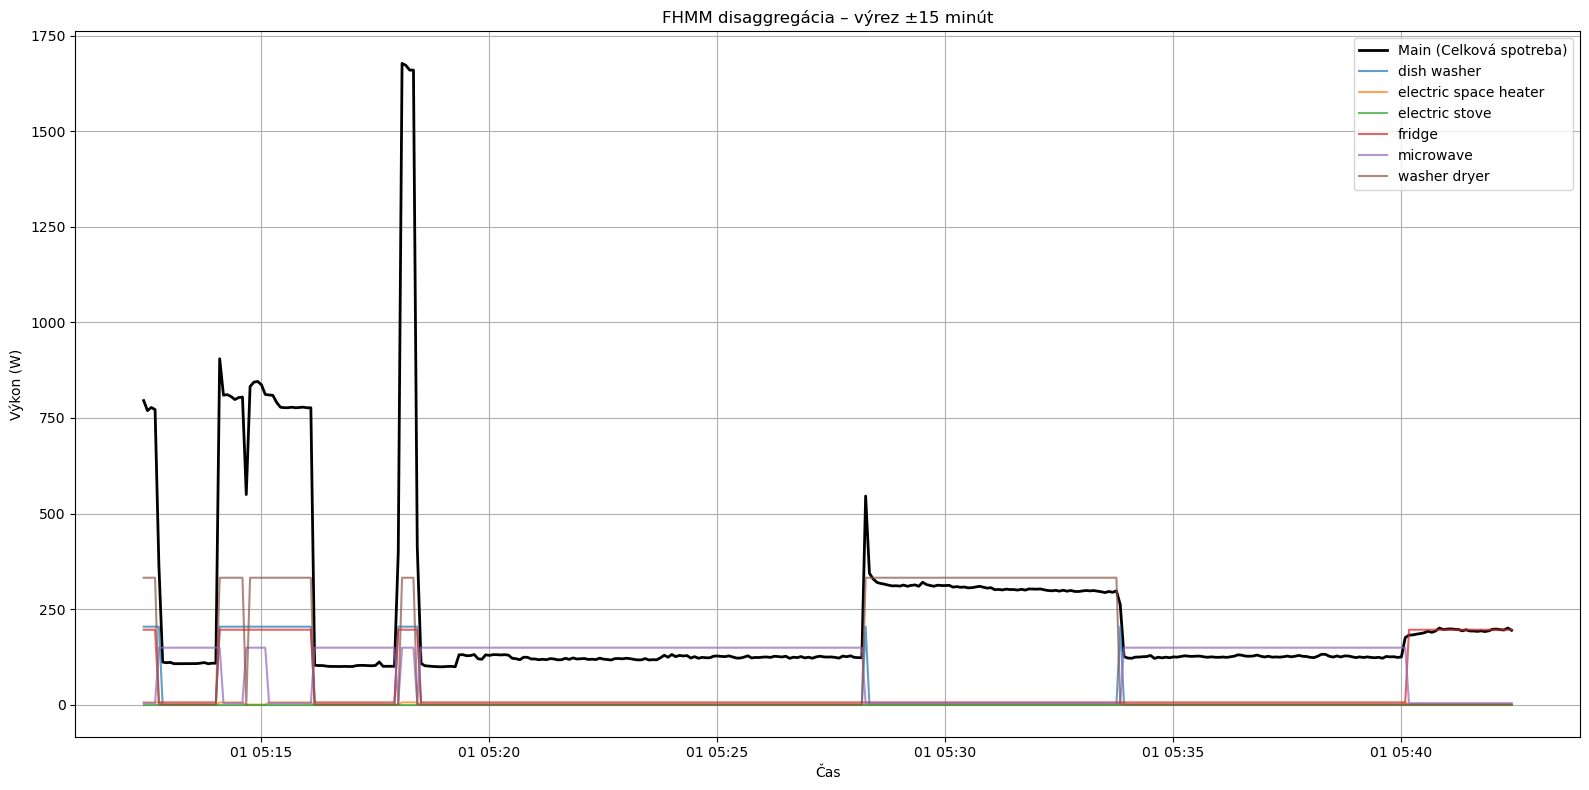

In [34]:
import random

# Výber náhodného časového bodu
random_index = random.randint(100, len(test_df) - 100)
center_time = test_df.loc[random_index, 'timestamp']

# Definícia časového okna
start_time = center_time - timedelta(minutes=15)
end_time = center_time + timedelta(minutes=15)

# Výber z test_df podľa 'timestamp'
test_window = test_df[(test_df['timestamp'] >= start_time) & (test_df['timestamp'] <= end_time)]

# Výber z predictions podľa indexu, ak indexy sú rovnaké ako v test_df (časové)
predictions_window = predictions[(predictions.index >= start_time) & (predictions.index <= end_time)]

# Vizualizácia výrezu
plt.figure(figsize=(16, 8))
plt.plot(test_window['timestamp'], test_window['main'], label='Main (Celková spotreba)', color='black', linewidth=2)      
for appliance in appliance_list:
    plt.plot(predictions_window.index, predictions_window[appliance], label=appliance, alpha=0.7)


plt.title("FHMM disaggregácia – výrez ±15 minút")
plt.xlabel("Čas")
plt.ylabel("Výkon (W)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
# Interval medzi vzorkami v sekundách (5 sekúnd pri downsampled REDD)
sample_interval_seconds = 5
seconds_to_hours = sample_interval_seconds / 3600

# Výpočet skutočnej spotreby pre každý spotrebič (Wh)
true_energy_Wh = {}
for appliance in appliance_list:
    if appliance in train_df_combined.columns:
        true_energy = train_df_combined[appliance].sum() * seconds_to_hours    
        true_energy_Wh[appliance] = round(true_energy, 2)
    else:
        true_energy_Wh[appliance] = None

# Výpočet predikovanej spotreby + percentuálnej zhody
comparison_stats = []
for appliance in appliance_list:
    pred_energy = predictions[appliance].sum() * seconds_to_hours
    true_energy = true_energy_Wh.get(appliance)


    comparison_stats.append({
        "Spotrebič": appliance,
        "Skutočná spotreba (Wh)": true_energy,
        "Predikovaná spotreba (Wh)": round(pred_energy, 2),
    })

# Výstupná tabuľka
comparison_df = pd.DataFrame(comparison_stats)
print(comparison_df)

               Spotrebič  Skutočná spotreba (Wh)  Predikovaná spotreba (Wh)
0            dish washer                 1214.45                     972.97
1  electric space heater                    5.60                      42.39
2         electric stove                    5.08                       0.00
3                 fridge                 2875.94                     672.42
4              microwave                  957.18                    1122.97
5           washer dryer                  814.31                     988.62



Výsledky disaggregácie (FHMM):
MAE: 71.36 W
MSE: 86710.27 W²
RMSE: 294.47 W


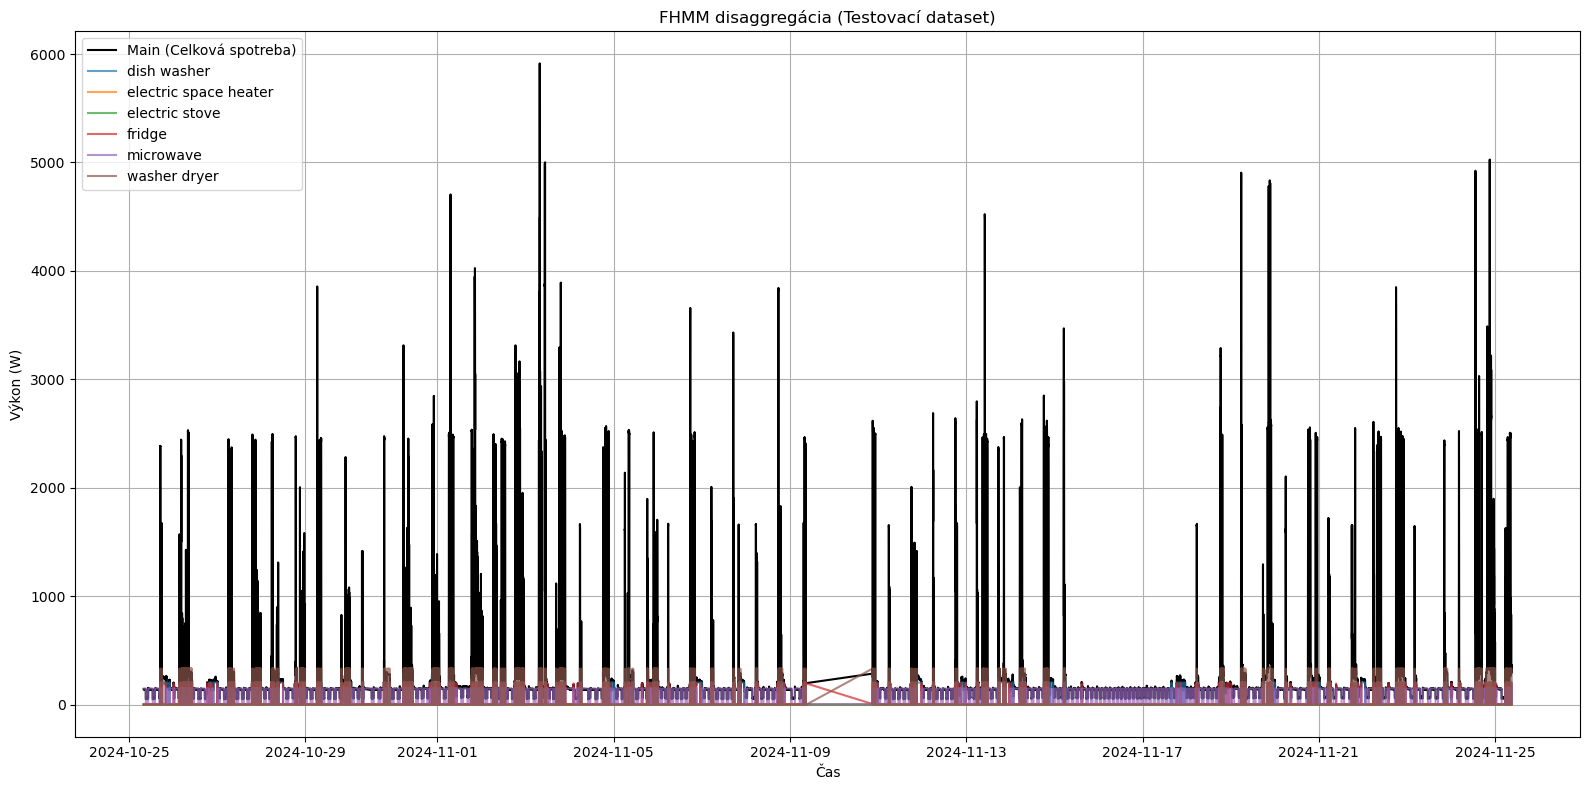

In [12]:
import json
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Načítanie JSON datasetu
with open("data.json", "r") as f:
    json_data = json.load(f)

# Prevod JSON do DataFrame
data_list = json_data['data']
df = pd.DataFrame([{
    'timestamp': datetime.fromtimestamp(entry['timestamp']),
    'main': entry['P']['L1']
} for entry in data_list])

# Tvorba stĺpca 'power'
df['power'] = df['main']

# Disaggregácia cez FHMM model
disaggregated_df = model2.disaggregate(df)

# Kontrola, či nie je None
if disaggregated_df is None:
    raise ValueError("Disaggregácia vrátila None. Skontroluj vstupné dáta a formát.")     
                                                                                                        
# Výpočet presnosti
sum_disagg = disaggregated_df.sum(axis=1)
mae = mean_absolute_error(df['main'], sum_disagg)
mse = mean_squared_error(df['main'], sum_disagg)
rmse = np.sqrt(mse)


print("\nVýsledky disaggregácie (FHMM):")
print(f"MAE: {mae:.2f} W")
print(f"MSE: {mse:.2f} W²")
print(f"RMSE: {rmse:.2f} W")


# Vizualizácia
plt.figure(figsize=(16, 8))
plt.plot(df['timestamp'], df['main'], label='Main (Celková spotreba)', color='black')
for col in disaggregated_df.columns:
    plt.plot(df['timestamp'], disaggregated_df[col], label=col, alpha=0.7)

plt.xlabel('Čas')
plt.ylabel('Výkon (W)')
plt.title('FHMM disaggregácia (Testovací dataset)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

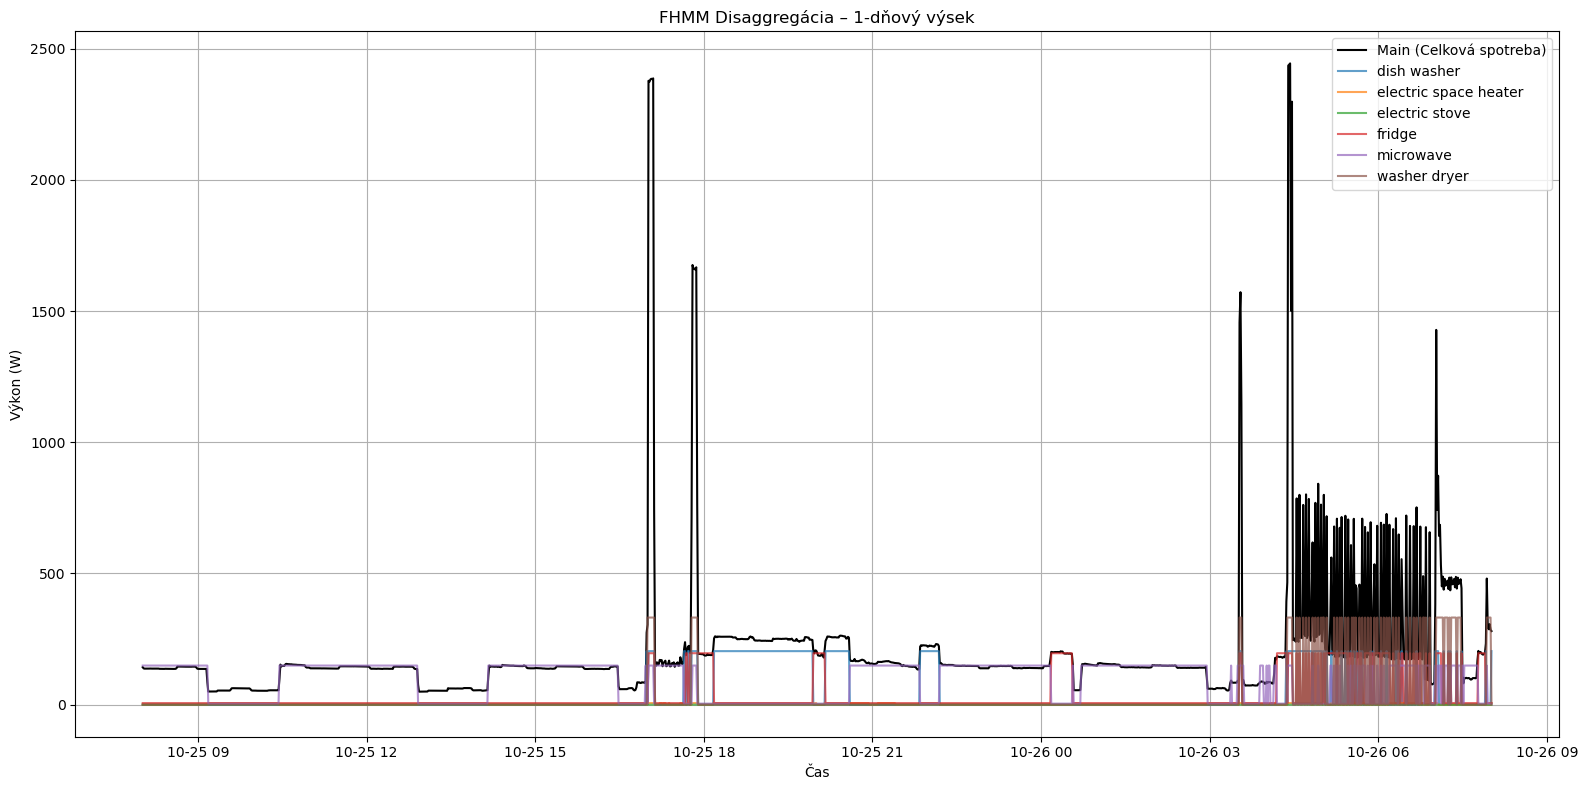

In [46]:
# Výber časového intervalu
start_time_2d = df['timestamp'].min()
end_time_2d = start_time_2d + pd.Timedelta(days= 1)

# Výber výseku dát
mask_2day = (df['timestamp'] >= start_time_2d) & (df['timestamp'] <= end_time_2d)
df_2day = df[mask_2day].copy()
disaggregated_2day = disaggregated_df[mask_2day.values].copy()

# Pridanie timestampu do disaggregovaných dát
disaggregated_2day['timestamp'] = df_2day['timestamp'].values

# Vizualizácia výseku
plt.figure(figsize=(16, 8))
plt.plot(df_2day['timestamp'], df_2day['main'], label='Main (Celková spotreba)', color='black')   
for col in disaggregated_2day.columns.drop('timestamp'):
    plt.plot(disaggregated_2day['timestamp'], disaggregated_2day[col], label=col, alpha=0.7)

plt.xlabel('Čas')
plt.ylabel('Výkon (W)')
plt.title('FHMM Disaggregácia – 1-dňový výsek')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()